<a href="https://colab.research.google.com/github/SujalGodse/Advance-Analytics-using-Statistics/blob/main/Advance_Analytics_using_Statistics_Day22.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# **TimeSeries**

In [ ]:
import statsmodels.api as sm
from statsmodels.formula.api import ols
import statsmodels.stats.multicomp
import sklearn
from sklearn.model_selection import train_test_split

from sklearn.linear_model import LinearRegression


import numpy as np
import pandas as pd
import warnings
warnings.filterwarnings("ignore")
pd.set_option('display.max_columns', None)
from numpy import random
from collections import Counter
from numpy.linalg import inv
from numpy.linalg import eig
import matplotlib
from matplotlib import pyplot as plt
import seaborn as sns
import pylab
from pylab import legend
from pylab import plot, show, title, xlabel, ylabel
import scipy
from scipy import stats
from scipy.stats import binom,poisson,norm,t,expon,f
from sklearn.model_selection import train_test_split

import statsmodels
from statsmodels import stats
from statsmodels.stats import weightstats as ssw

import statsmodels.api as sm
from statsmodels.formula.api import ols
import statsmodels.stats.multicomp

from statsmodels.discrete.discrete_model import MNLogit

from sklearn.tree import DecisionTreeClassifier

import statsmodels.stats
from statsmodels.stats.proportion import proportions_ztest

from scipy.stats import chisquare

from scipy.stats import chi2_contingency

from statsmodels.stats import rates
from statsmodels.stats.rates import test_poisson

from statsmodels.stats.rates import test_poisson_2indep

from scipy.stats import chi2

In [ ]:
from statsmodels.tsa.seasonal import seasonal_decompose
from sklearn.metrics import mean_squared_error
from math import sqrt

df = pd.read_excel('/content/drive/MyDrive/CDAC/CDAC_DataBook.xlsx',sheet_name='birth')
df.head()

,BirthRate
0,26.663
1,23.598
2,26.931
3,24.740
4,25.806


<Axes: >

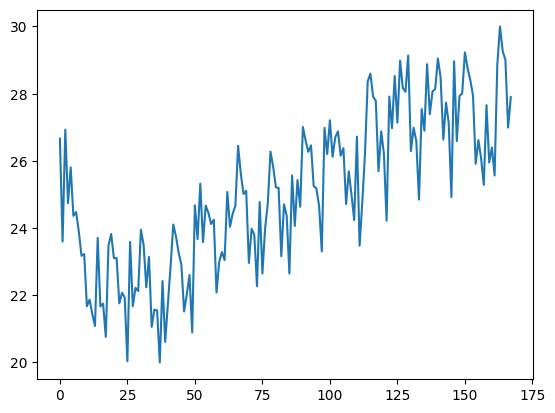

In [ ]:
df.BirthRate.plot()

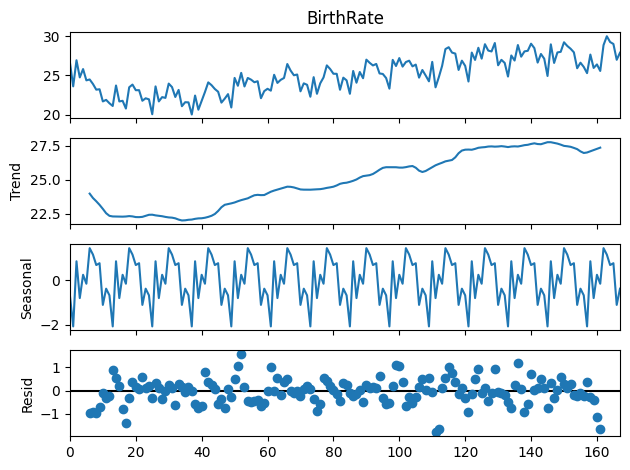

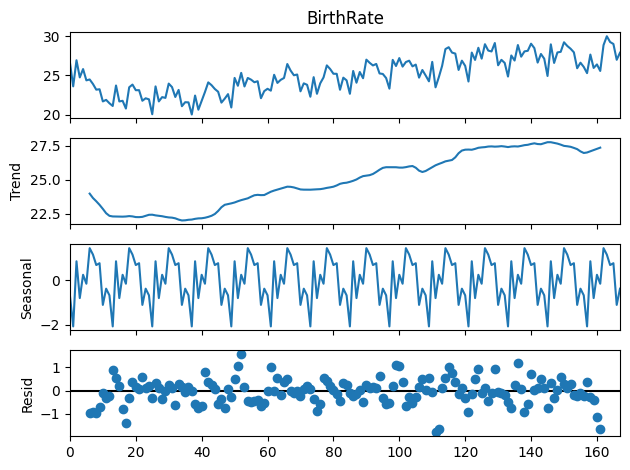

In [ ]:
from statsmodels.tsa.seasonal import seasonal_decompose as ssd
ssd(df.BirthRate,period=12).plot()

In [ ]:
# dataset preparation

df_train = df.iloc[:144]
df_test = df.iloc[144:]
df_train.shape,df_test.shape

((144, 1), (24, 1))

## **Prediction Technique**

### **Naive Method**

In [ ]:
df_test['naive'] = df_train.BirthRate.iloc[-1]
df_test.head()

,BirthRate,naive
144,27.132,27.735
145,24.924,27.735
146,28.963,27.735
147,26.589,27.735
148,27.931,27.735


In [ ]:
# RMSE - Root Mean Squared Error
sqrt(mean_squared_error(df_test.BirthRate,df_test.naive))

1.4277309211939526

### **Simple Avrage Method**

In [ ]:
df_test['simple_avg'] = df_train.BirthRate.mean()
sqrt(mean_squared_error(df_test.BirthRate,df_test.simple_avg))

3.147657647627305

### **Months Moving Average**

In [ ]:
# 12 months moving average
df_test['12MthsMovingAvg'] = df_train.BirthRate.iloc[-12:].mean()
sqrt(mean_squared_error(df_test.BirthRate, df_test['12MthsMovingAvg']))
# 1.40448108

1.4044810849760687

In [ ]:
# 24 months moving average
df_test['24MthsMovingAvg'] = df_train.BirthRate.iloc[-24:].mean()
sqrt(mean_squared_error(df_test.BirthRate, df_test['24MthsMovingAvg']))
# 1.40386

1.4038687245726835

### **Weighted Moving Average**

In [ ]:
# the latest one will get largest weight and the oldest one will get smallest and other will be getiing according to their oreder

In [ ]:
# 12 months weighted average
wts = np.arange(12,0,-1)
df_test['WMA'] = (df_train.BirthRate.iloc[-12:]*wts).sum()/wts.sum()
sqrt(mean_squared_error(df_test.BirthRate, df_test.WMA))

1.4238115558763185

### **Simple Exponential Smoothing**

In [ ]:
from statsmodels.tsa.api import SimpleExpSmoothing
x1=np.array([7,6,8,5,9,7,5,7,6,8,9,4,6,5,6])
mod1 = SimpleExpSmoothing(x1).fit(smoothing_level=0.8, optimized=False)
mod1.forecast(1)

array([5.83156084])

In [ ]:
mod1 = SimpleExpSmoothing(df_train.BirthRate).fit(smoothing_level=0.8, optimized=False)
df_test['SES'] = mod1.forecast(24)
sqrt(mean_squared_error(df_test.BirthRate, df_test.SES))

1.4086237555629835

### **Holt's Linear Trend Method**

In [ ]:
from statsmodels.tsa.api import Holt
mod2 = Holt(df_train.BirthRate).fit(smoothing_level=0.8)
df_test['HoltLinear'] = mod2.forecast(24)
sqrt(mean_squared_error(df_test.BirthRate, df_test.HoltLinear))

1.500895536001304

### **Holt's Winter's Method**

In [ ]:
# Holt-Winter's method - used when we have both trend and seasonal variation
from statsmodels.tsa.api import ExponentialSmoothing
mod3 = ExponentialSmoothing(df_train.BirthRate,seasonal_periods=12).fit()
df_test['HoltWinter'] = mod3.forecast(24)
sqrt(mean_squared_error(df_test.BirthRate, df_test.HoltWinter))

1.4207646015778608

### **ARIMA(Auto Regressive Integrated Moving Average) Method**

In [ ]:
from statsmodels.tsa.stattools import adfuller
adfuller(df_train)

(np.float64(0.2017160479163269),
 np.float64(0.9723576777571017),
 13,
 130,
 {'1%': np.float64(-3.4816817173418295),
  '5%': np.float64(-2.8840418343195267),
  '10%': np.float64(-2.578770059171598)},
 np.float64(322.55907506392055))

In [ ]:
df_train1 = df_train.diff().dropna()
adfuller(df_train1)

(np.float64(-4.253904918858687),
 np.float64(0.0005333378978881231),
 14,
 128,
 {'1%': np.float64(-3.4825006939887997),
  '5%': np.float64(-2.884397984161377),
  '10%': np.float64(-2.578960197753906)},
 np.float64(314.64706729275866))

<Axes: >

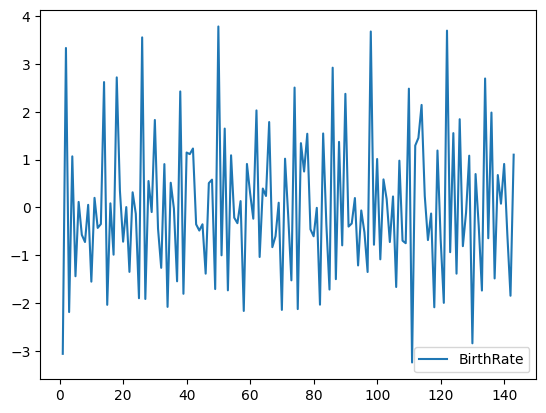

In [ ]:
df_train1.plot()

Figure(640x480)
Figure(640x480)


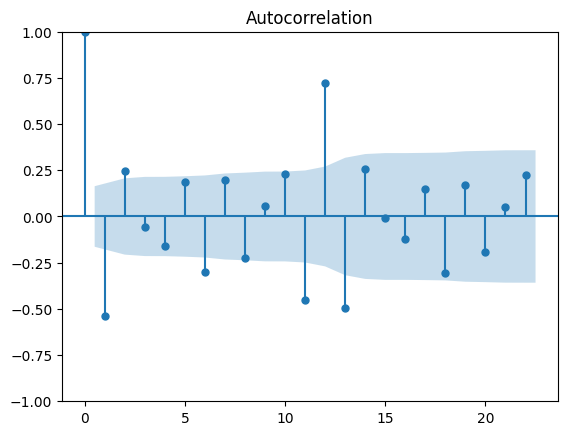

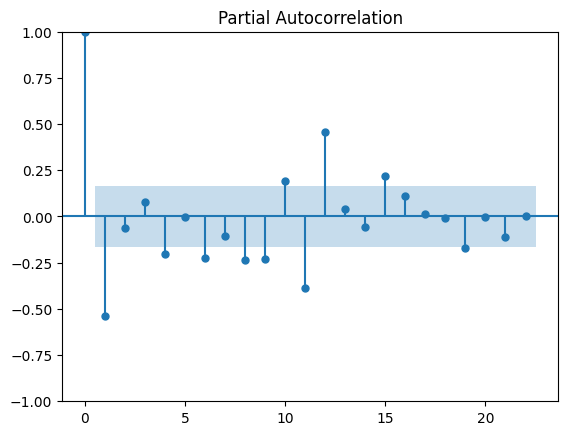

In [ ]:
from statsmodels.graphics.tsaplots import plot_acf,plot_pacf
print(plot_acf(df_train.diff().dropna()))
print(plot_pacf(df_train.diff().dropna()))